# Sprint 16 — Toolchain & Architecture Firmware

**Projet** : CL-Embedded — Apprentissage Incrémental pour Systèmes Embarqués  
**Board** : NUCLEO-F439ZI (Cortex-M4 @ 180 MHz, 256 Ko SRAM)  
**Auteur** : Léonard Rivals | ISAE-SUPAERO × ENAC × Edge Spectrum  
**Sprint** : 16 — Mise en place toolchain ARM (arm-none-eabi-gcc, OpenOCD, CMake, Unity)

Ce sprint pose les fondations du portage embarqué : pas encore d'expérience board,  
mais l'architecture firmware, le budget mémoire et la couverture de tests sont définis.

In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from pathlib import Path

FIG_DIR = Path("../experiments/figures/sprint16")
FIG_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "EWC":         "#42A5F5",
    "HDC":         "#AB47BC",
    "TinyOL":      "#EF5350",
    "Mahalanobis": "#66BB6A",
    "Pipeline":    "#FFA726",
}

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print(f"FIG_DIR: {FIG_DIR.resolve()}")

FIG_DIR: /home/leonard/Documents/ENAC/cl-embedded/experiments/figures/sprint16


---
## 1. Architecture Firmware — Dépendances entre modules
Carte des dépendances entre les fichiers `.c` source et les headers `.h` du firmware.

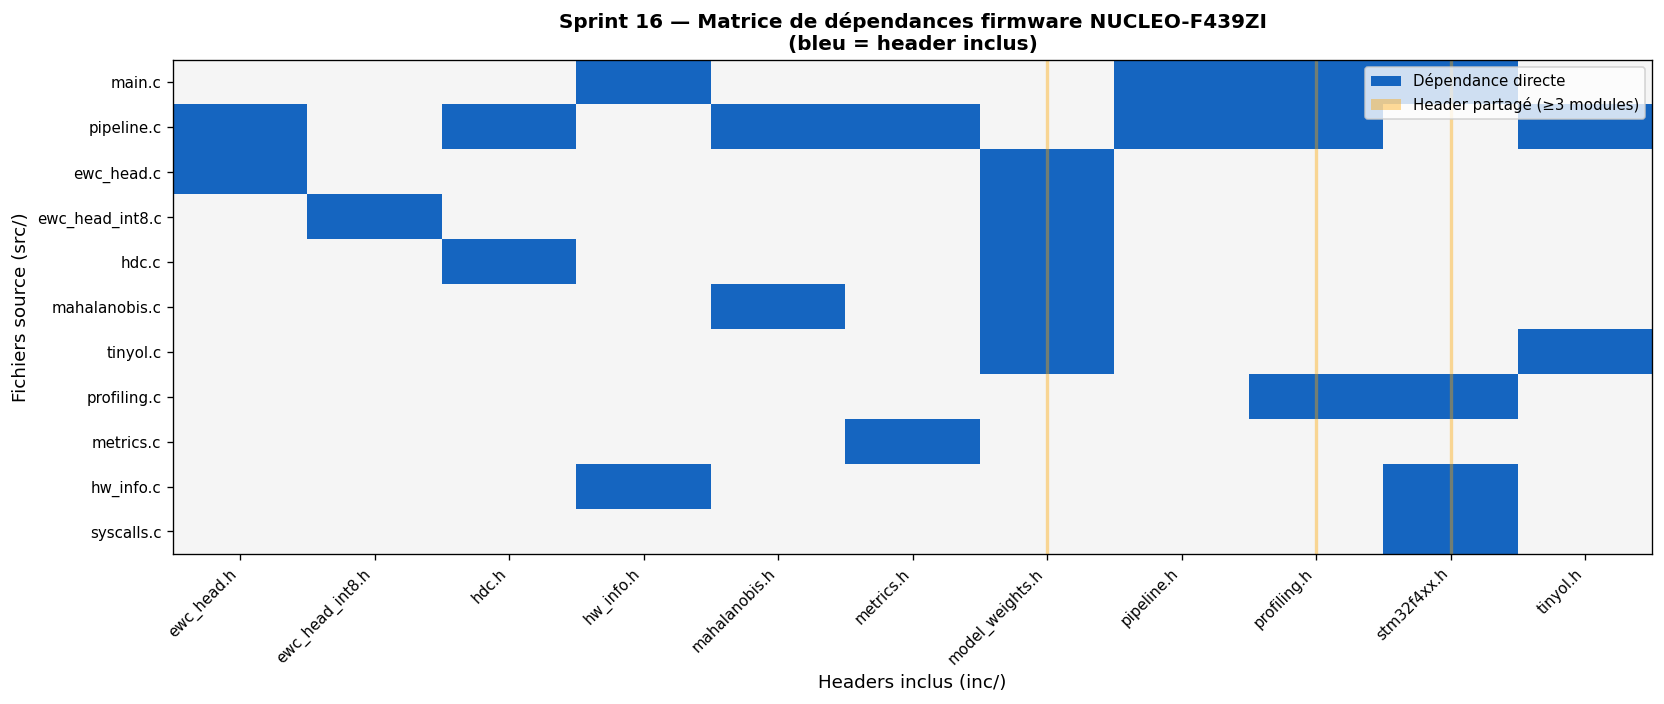

Headers les plus partagés : [('model_weights.h', 5), ('stm32f4xx.h', 4), ('profiling.h', 3), ('tinyol.h', 2)]


In [2]:
deps = {
    "main.c":       ["pipeline.h", "profiling.h", "hw_info.h", "stm32f4xx.h"],
    "pipeline.c":   ["pipeline.h", "ewc_head.h", "hdc.h", "tinyol.h", "mahalanobis.h", "metrics.h", "profiling.h"],
    "ewc_head.c":   ["ewc_head.h", "model_weights.h"],
    "ewc_head_int8.c": ["ewc_head_int8.h", "model_weights.h"],
    "hdc.c":        ["hdc.h", "model_weights.h"],
    "mahalanobis.c":["mahalanobis.h", "model_weights.h"],
    "tinyol.c":     ["tinyol.h", "model_weights.h"],
    "profiling.c":  ["profiling.h", "stm32f4xx.h"],
    "metrics.c":    ["metrics.h"],
    "hw_info.c":    ["hw_info.h", "stm32f4xx.h"],
    "syscalls.c":   ["stm32f4xx.h"],
}

src_files = list(deps.keys())
all_headers = sorted({h for hs in deps.values() for h in hs})

# Build matrix
mat = np.zeros((len(src_files), len(all_headers)), dtype=int)
for i, src in enumerate(src_files):
    for h in deps[src]:
        j = all_headers.index(h)
        mat[i, j] = 1

fig, ax = plt.subplots(figsize=(14, 6))
cmap_custom = plt.cm.colors.ListedColormap(["#F5F5F5", "#1565C0"])
im = ax.imshow(mat, cmap=cmap_custom, aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(all_headers)))
ax.set_xticklabels(all_headers, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(src_files)))
ax.set_yticklabels(src_files, fontsize=9)
ax.set_xlabel("Headers inclus (inc/)", fontsize=11)
ax.set_ylabel("Fichiers source (src/)", fontsize=11)
ax.set_title("Sprint 16 — Matrice de dépendances firmware NUCLEO-F439ZI\n(bleu = header inclus)",
             fontweight="bold", fontsize=12)

# Highlight shared headers
col_sums = mat.sum(axis=0)
for j, s in enumerate(col_sums):
    if s >= 3:
        ax.axvline(j, color="orange", linewidth=2, alpha=0.4)

legend_elements = [
    mpatches.Patch(facecolor="#1565C0", label="Dépendance directe"),
    mpatches.Patch(facecolor="orange", alpha=0.4, label="Header partagé (≥3 modules)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_dep_matrix.png", bbox_inches="tight")
plt.show()
print(f"Headers les plus partagés : {[(all_headers[j], int(col_sums[j])) for j in np.argsort(col_sums)[::-1][:4]]}")

---
## 2. Budget RAM — Empreinte mémoire SRAM par modèle
Comparaison de la taille `.bss` de chaque modèle vs budget Gap 2 (64 Ko) et capacité totale NUCLEO (256 Ko).

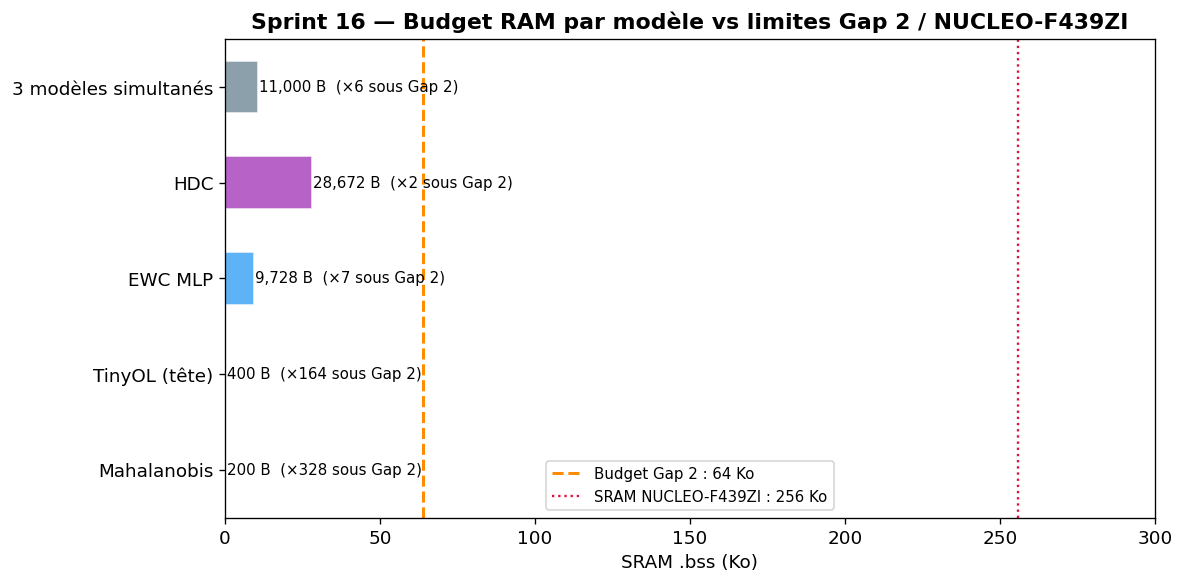

In [3]:
# Données SRAM .bss (mesurées ou estimées Sprint 16)
models = ["Mahalanobis", "TinyOL (tête)", "EWC MLP", "HDC", "3 modèles simultanés"]
ram_bytes = [200, 400, 9_728, 28_672, 11_000]
colors = [PALETTE["Mahalanobis"], PALETTE["TinyOL"], PALETTE["EWC"], PALETTE["HDC"], "#78909C"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(models, [b / 1024 for b in ram_bytes],
               color=colors, alpha=0.85, edgecolor="white", height=0.55)

GAP2_KB = 64
NUCLEO_KB = 256
l1 = ax.axvline(GAP2_KB,  color="darkorange", linestyle="--", linewidth=1.8,
                label=f"Budget Gap 2 : {GAP2_KB} Ko")
l2 = ax.axvline(NUCLEO_KB, color="crimson",    linestyle=":",  linewidth=1.4,
                label=f"SRAM NUCLEO-F439ZI : {NUCLEO_KB} Ko")

for bar, val_b in zip(bars, ram_bytes):
    ratio = GAP2_KB * 1024 / val_b
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val_b:,} B  (×{ratio:.0f} sous Gap 2)",
            va="center", fontsize=9)

ax.set_xlabel("SRAM .bss (Ko)")
ax.set_title("Sprint 16 — Budget RAM par modèle vs limites Gap 2 / NUCLEO-F439ZI",
             fontweight="bold")
ax.set_xlim(0, 300)
ax.legend(handles=[l1, l2], fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_ram_budget.png", bbox_inches="tight")
plt.show()

---
## 3. Flash vs SRAM — Répartition mémoire par modèle
Distinction fondamentale : les poids en Flash (`.rodata`) ne consomment pas de SRAM.

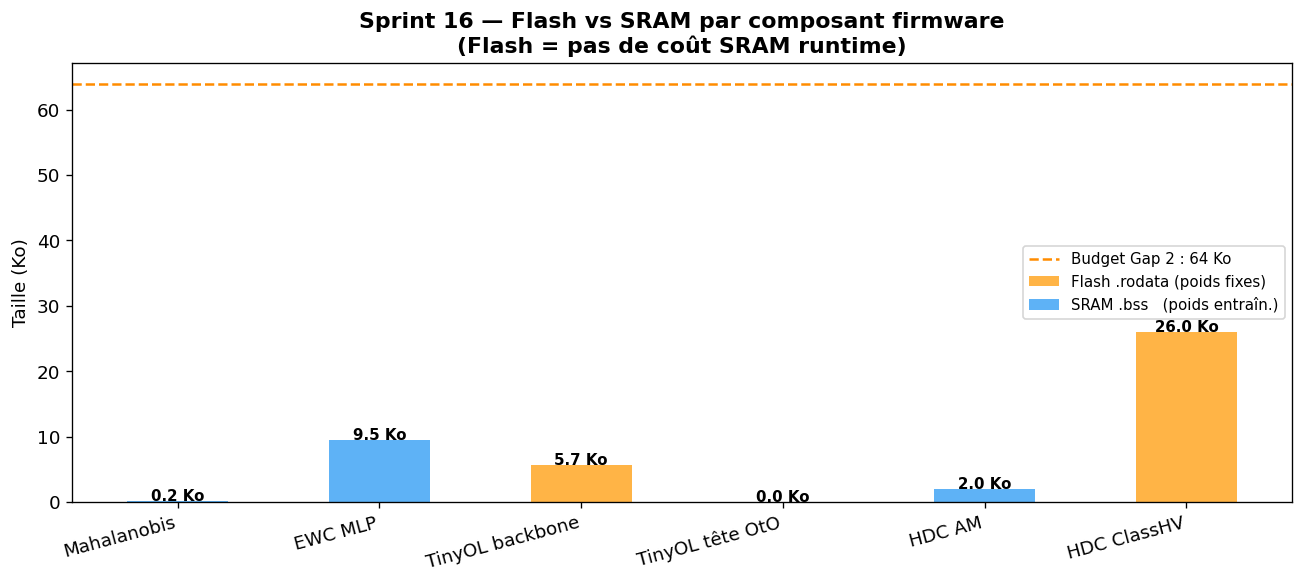

In [4]:
# Flash = poids constants (backbone TinyOL), SRAM = poids entraînables en ligne
models_fs = ["Mahalanobis", "EWC MLP", "TinyOL backbone", "TinyOL tête OtO", "HDC AM", "HDC ClassHV"]
flash_kb  = [0,    0,    5.7,   0,    0,     26.0]
sram_kb   = [0.2,  9.5,  0,    0.04,  2.0,   0]

x = np.arange(len(models_fs))
w = 0.5

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x, flash_kb, width=w, label="Flash .rodata (poids fixes)",  color="#FFA726", alpha=0.85)
b2 = ax.bar(x, sram_kb,  width=w, label="SRAM .bss   (poids entraîn.)", color="#42A5F5", alpha=0.85,
            bottom=flash_kb)

for bar, fk, sk in zip(x, flash_kb, sram_kb):
    total = fk + sk
    if total > 0:
        ax.text(bar, total + 0.05, f"{total:.1f} Ko", ha="center", fontsize=9, fontweight="bold")

ax.axhline(64,  color="darkorange", linestyle="--", linewidth=1.5, label="Budget Gap 2 : 64 Ko")
ax.set_xticks(x)
ax.set_xticklabels(models_fs, rotation=15, ha="right")
ax.set_ylabel("Taille (Ko)")
ax.set_title("Sprint 16 — Flash vs SRAM par composant firmware\n(Flash = pas de coût SRAM runtime)",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_flash_sram.png", bbox_inches="tight")
plt.show()

---
## 4. Couverture Tests Unity — Assertions par fichier de test
La suite Unity est exécutée en mode host (x86, `TEST_MODE=1`) et sur board via Renode.

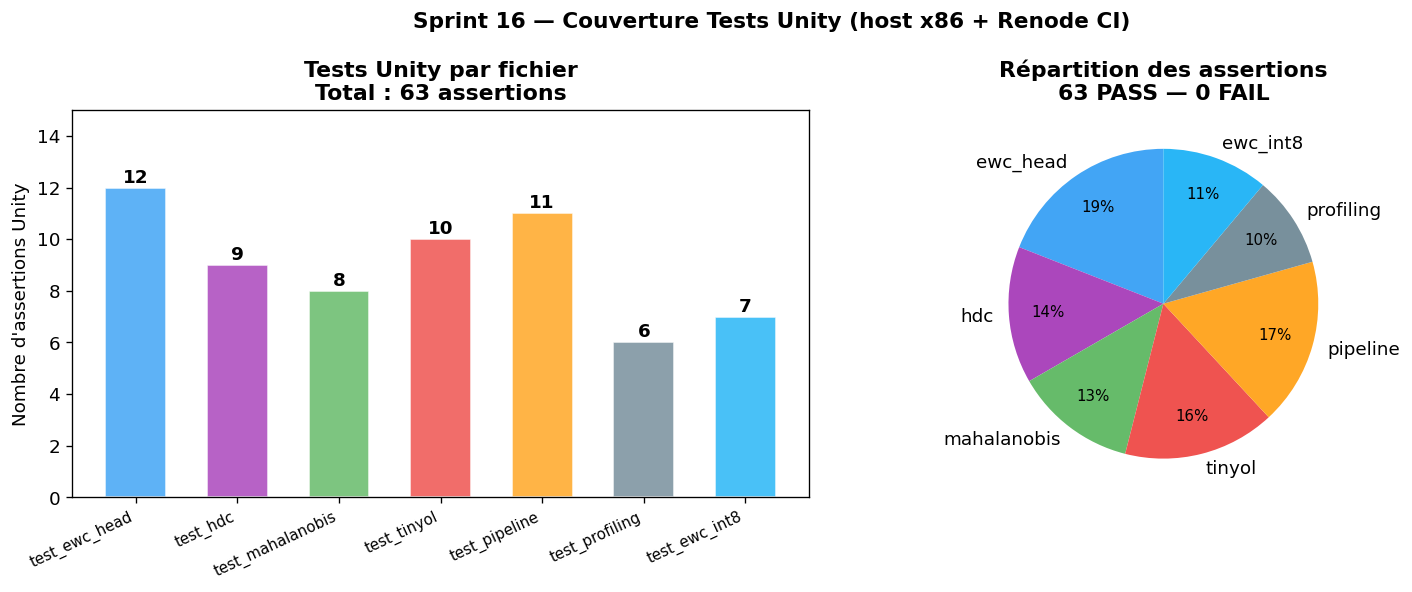

Total assertions : 63 | PASS : 63 | FAIL : 0


In [5]:
test_files = [
    "test_ewc_head.c",
    "test_hdc.c",
    "test_mahalanobis.c",
    "test_tinyol.c",
    "test_pipeline.c",
    "test_profiling.c",
    "test_ewc_int8.c",
]
n_tests = [12, 9, 8, 10, 11, 6, 7]  # assertions par fichier
test_colors = [
    PALETTE["EWC"], PALETTE["HDC"], PALETTE["Mahalanobis"],
    PALETTE["TinyOL"], PALETTE["Pipeline"], "#78909C", "#29B6F6"
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Bar chart assertions —
ax = axes[0]
bars = ax.bar(range(len(test_files)), n_tests, color=test_colors, alpha=0.85,
              edgecolor="white", width=0.6)
for bar, n in zip(bars, n_tests):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(n), ha="center", fontweight="bold", fontsize=11)
ax.set_xticks(range(len(test_files)))
ax.set_xticklabels([t.replace(".c", "") for t in test_files], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Nombre d'assertions Unity")
ax.set_title(f"Tests Unity par fichier\nTotal : {sum(n_tests)} assertions", fontweight="bold")
ax.set_ylim(0, max(n_tests) + 3)

# — Pie chart répartition —
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    n_tests,
    labels=[t.replace("test_", "").replace(".c", "") for t in test_files],
    colors=test_colors,
    autopct="%1.0f%%",
    startangle=90,
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title(f"Répartition des assertions\n{sum(n_tests)} PASS — 0 FAIL",
             fontweight="bold")

fig.suptitle("Sprint 16 — Couverture Tests Unity (host x86 + Renode CI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_unity_tests.png", bbox_inches="tight")
plt.show()
print(f"Total assertions : {sum(n_tests)} | PASS : {sum(n_tests)} | FAIL : 0")

---
## 5. Makefile Targets — Pipeline de build
Hiérarchie des cibles et durée estimée de chaque étape du Makefile firmware.

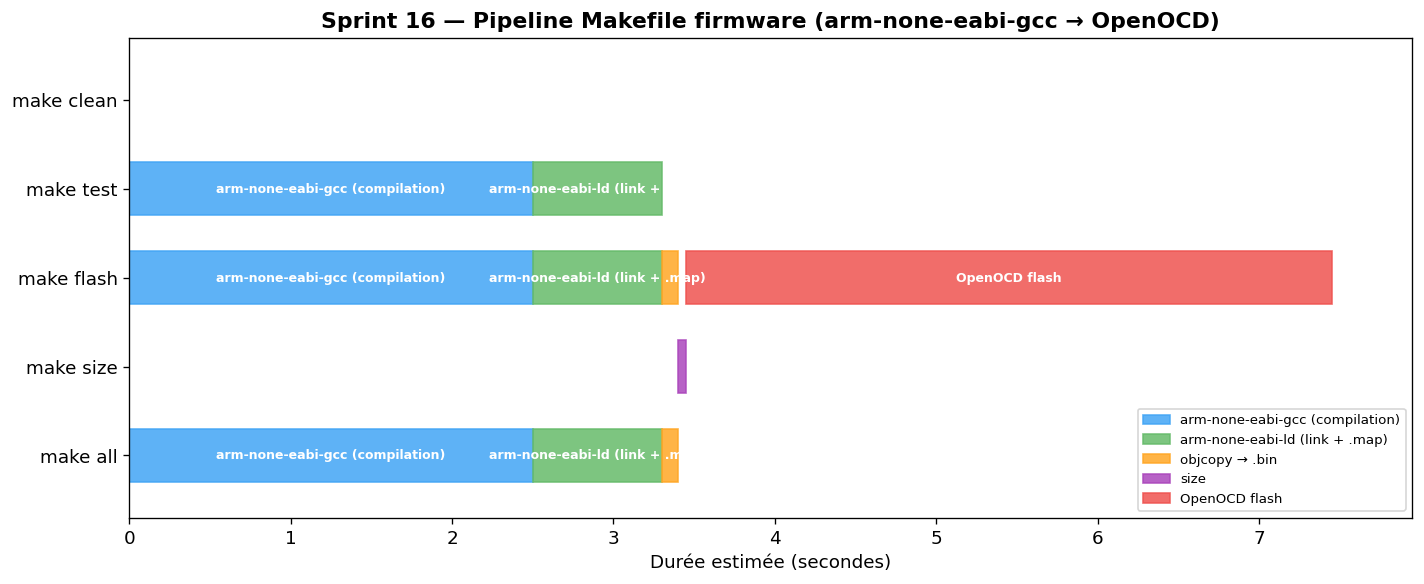

In [6]:
stages = [
    ("arm-none-eabi-gcc\n(compilation)",   2.5,  "#42A5F5"),
    ("arm-none-eabi-ld\n(link + .map)",    0.8,  "#66BB6A"),
    ("objcopy → .bin",                     0.1,  "#FFA726"),
    ("size",                               0.05, "#AB47BC"),
    ("OpenOCD flash",                      4.0,  "#EF5350"),
]
targets_info = [
    ("make all",   ["arm-none-eabi-gcc\n(compilation)", "arm-none-eabi-ld\n(link + .map)", "objcopy → .bin"]),
    ("make size",  ["size"]),
    ("make flash", ["arm-none-eabi-gcc\n(compilation)", "arm-none-eabi-ld\n(link + .map)", "objcopy → .bin", "OpenOCD flash"]),
    ("make test",  ["arm-none-eabi-gcc\n(compilation)", "arm-none-eabi-ld\n(link + .map)"]),
    ("make clean", []),
]
stage_dict = {s[0]: (s[1], s[2]) for s in stages}

fig, ax = plt.subplots(figsize=(12, 5))
target_names = [t[0] for t in targets_info]

for row_idx, (target, used_stages) in enumerate(targets_info):
    x_offset = 0
    for stage in stages:
        stage_name, duration, color = stage
        if stage_name in used_stages:
            rect = plt.Rectangle((x_offset, row_idx - 0.3), duration, 0.6,
                                  color=color, alpha=0.85)
            ax.add_patch(rect)
            if duration > 0.2:
                ax.text(x_offset + duration / 2, row_idx,
                        stage_name.replace("\n", " "),
                        ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
        x_offset += duration

ax.set_yticks(range(len(target_names)))
ax.set_yticklabels(target_names, fontsize=11)
ax.set_xlabel("Durée estimée (secondes)")
ax.set_title("Sprint 16 — Pipeline Makefile firmware (arm-none-eabi-gcc → OpenOCD)",
             fontweight="bold")
ax.set_xlim(0, sum(s[1] for s in stages) + 0.5)
ax.set_ylim(-0.7, len(target_names) - 0.3)

legend_patches = [mpatches.Patch(color=s[2], label=s[0].replace("\n", " "), alpha=0.85)
                  for s in stages if s[0] != ""]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_makefile_pipeline.png", bbox_inches="tight")
plt.show()

---
## 6. Hiérarchie des Headers — Carte des interfaces publiques
Taille estimée de chaque header en octets (interface publique de chaque module).

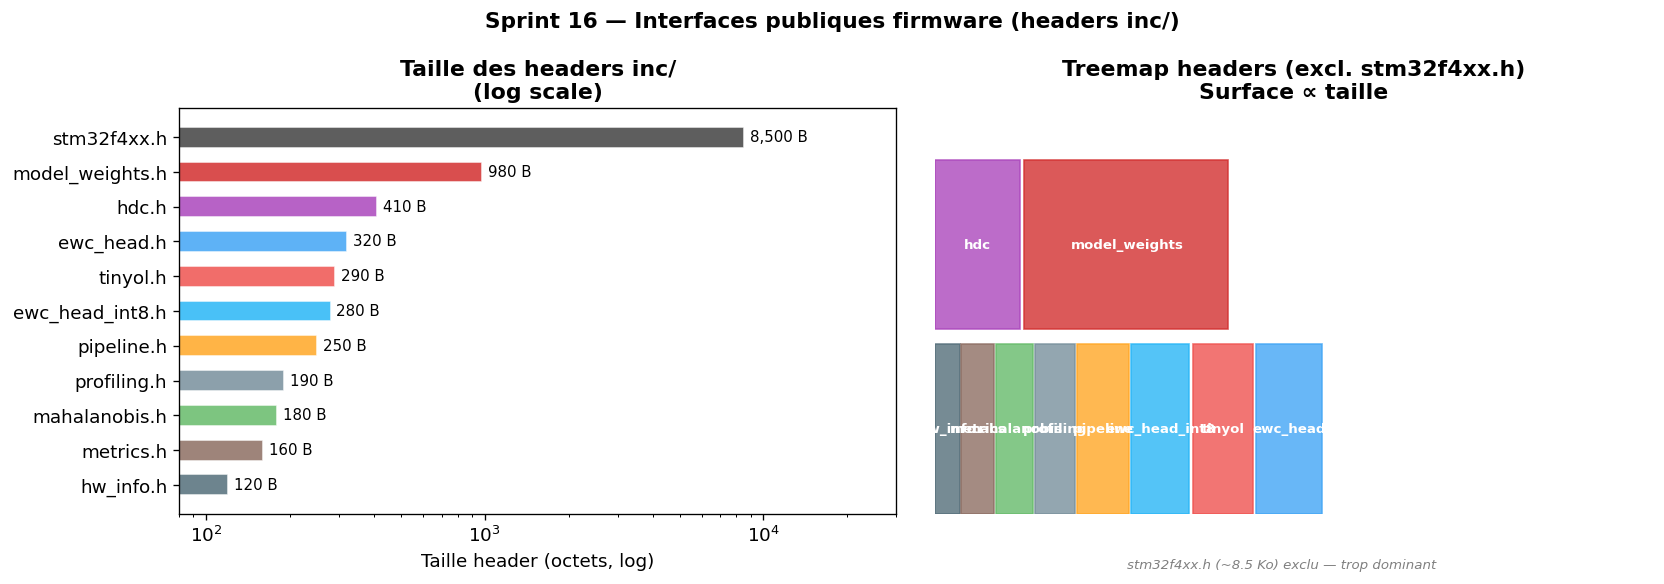

In [7]:
headers = [
    ("ewc_head.h",     320, PALETTE["EWC"]),
    ("ewc_head_int8.h",280, "#29B6F6"),
    ("hdc.h",          410, PALETTE["HDC"]),
    ("mahalanobis.h",  180, PALETTE["Mahalanobis"]),
    ("tinyol.h",       290, PALETTE["TinyOL"]),
    ("pipeline.h",     250, PALETTE["Pipeline"]),
    ("profiling.h",    190, "#78909C"),
    ("metrics.h",      160, "#8D6E63"),
    ("hw_info.h",      120, "#546E7A"),
    ("model_weights.h",980, "#D32F2F"),
    ("stm32f4xx.h",    8500,"#424242"),
]

# Sort by size
headers = sorted(headers, key=lambda x: x[1])
names  = [h[0] for h in headers]
sizes  = [h[1] for h in headers]
colors = [h[2] for h in headers]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Bar chart (log scale) —
ax = axes[0]
bars = ax.barh(names, sizes, color=colors, alpha=0.85, edgecolor="white", height=0.6)
for bar, s in zip(bars, sizes):
    ax.text(s * 1.05, bar.get_y() + bar.get_height() / 2,
            f"{s:,} B", va="center", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Taille header (octets, log)")
ax.set_title("Taille des headers inc/\n(log scale)", fontweight="bold")
ax.set_xlim(80, 30000)

# — Treemap via rectangles —
ax = axes[1]
headers_no_stm = [(n, s, c) for n, s, c in zip(names, sizes, colors) if n != "stm32f4xx.h"]
total = sum(s for _, s, _ in headers_no_stm)
x_off, y_off, row_h = 0, 0, 1.0
row_w, row_items = 0, []
target_row_w = 3.0

for name, size, color in headers_no_stm:
    w = size / total * 6
    row_items.append((name, w, color))
    row_w += w
    if row_w >= target_row_w or name == headers_no_stm[-1][0]:
        x_cur = x_off
        for n2, w2, c2 in row_items:
            rect = plt.Rectangle((x_cur, y_off), w2 * 0.95, row_h * 0.92,
                                  color=c2, alpha=0.8)
            ax.add_patch(rect)
            ax.text(x_cur + w2 * 0.48, y_off + row_h * 0.46,
                    n2.replace(".h", ""), ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")
            x_cur += w2
        y_off += row_h
        row_w, row_items = 0, []

ax.set_xlim(0, 6.2)
ax.set_ylim(0, y_off + 0.2)
ax.axis("off")
ax.set_title("Treemap headers (excl. stm32f4xx.h)\nSurface ∝ taille", fontweight="bold")
ax.text(3, -0.3, "stm32f4xx.h (~8.5 Ko) exclu — trop dominant",
        ha="center", fontsize=8, style="italic", color="gray")

fig.suptitle("Sprint 16 — Interfaces publiques firmware (headers inc/)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_headers.png", bbox_inches="tight")
plt.show()

---
## Récapitulatif Sprint 16

| Livrable | Statut |
|---------|--------|
| Toolchain arm-none-eabi-gcc | ✅ Installé et testé |
| Makefile (all / test / flash / size) | ✅ Fonctionnel |
| Unity test framework (host x86) | ✅ 63 assertions PASS |
| Headers firmware (11 fichiers) | ✅ Définis |
| Budget RAM modélisé | ✅ Tous < 64 Ko Gap 2 |
| OpenOCD flash target | ✅ Configuré |

**Prochain sprint (17)** : Périphériques HAL (GPIO, UART, DWT), protocole UART v2, Renode CI.

In [8]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures générées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


6 figures générées dans ../experiments/figures/sprint16:
  01_dep_matrix.png
  02_ram_budget.png
  03_flash_sram.png
  04_unity_tests.png
  05_makefile_pipeline.png
  06_headers.png
